In [4]:
#Loading the saved CSV files for further processing and model training.
import numpy as np
import pandas as pd

X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv")
y_test = pd.read_csv("y_test.csv")

print("Data loaded successfully!")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data loaded successfully!
X_train shape: (770, 28)
X_test shape: (193, 28)
y_train shape: (770, 1)
y_test shape: (193, 1)


In [1]:
# Required Libraries
import numpy as np
import matplotlib.pyplot as plt

In [5]:
def initialize_parameters(dim):
    """
    Initializes the model's weights to zeros and the bias to zero.
    
    Argument:
    dim -- the number of features in the training data
    
    Returns:
    w -- initialized weight vector of shape (dim, 1)
    b -- initialized scalar bias (0.0)
    """
    w = np.zeros((dim, 1))
    b = 0.0
    return w, b

# Determine the number of features from X_train and initialize parameters
n_features = X_train.shape[1]
w, b = initialize_parameters(n_features)

print("Parameters initialized successfully!")
print(f"Weights shape: {w.shape}")
print(f"Bias value: {b}")

Parameters initialized successfully!
Weights shape: (28, 1)
Bias value: 0.0


In [6]:
#Sigmoid function to map any real value into the range [0, 1]
def sigmoid(z):
    """
    Compute the sigmoid of z

    Arguments:
    z -- A scalar or numpy array of any size.

    Return:
    s -- sigmoid(z)
    """
    s = 1 / (1 + np.exp(-z))
    return s

In [7]:
#Binary cross-entropy cost function to evaluate the performance of the model
def compute_cost(A, Y):
    """
    Computes the binary cross-entropy cost.
    
    Arguments:
    A -- sigmoid output of shape (1, number of examples) or matching Y
    Y -- true "label" vector of shape (1, number of examples) or matching Y
    
    Returns:
    cost -- cross-entropy cost
    """
    m = Y.shape[0] if isinstance(Y, np.ndarray) else len(Y)
    
    # Adding a tiny epsilon to prevent log(0) errors
    epsilon = 1e-15
    A = np.clip(A, epsilon, 1 - epsilon)
    
    # Computing cost
    cost = -1/m * np.sum(Y * np.log(A) + (1 - Y) * np.log(1 - A))
    
    # Ensuring cost is a scalar
    cost = np.squeeze(cost)
    
    return cost

In [8]:
#Forward and backward propagation to compute gradients and cost
def propagate(w, b, X, Y):
    """
    Implement the cost function and its gradient for the propagation.

    Arguments:
    w -- weights, a numpy array of size (number of features, 1)
    b -- bias, a scalar
    X -- data of size (number of features, number of examples)
    Y -- true "label" vector of size (1, number of examples)

    Returns:
    grads -- dictionary containing the gradients of the weights and bias
    cost -- binary cross-entropy cost
    """
    
    m = X.shape[1]  # number of examples

    # Forward propagation
    Z = np.dot(w.T, X) + b  # Linear combination
    A = sigmoid(Z)          # Activation
    cost = compute_cost(A, Y)  # Compute cost

    # Backward propagation
    dZ = A - Y              # Derivative of cost with respect to Z
    dw = (1/m) * np.dot(X, dZ.T)  # Gradient with respect to weights
    db = (1/m) * np.sum(dZ)        # Gradient with respect to bias

    grads = {"dw": dw, "db": db}

    return grads, cost

In [9]:
# Force-convert the data into clean numeric float arrays for NumPy
X_train = np.array(X_train, dtype=float)
y_train = np.array(y_train, dtype=float)

In [10]:
# Automatically matching the 'w' to the number of features the dataset has
w = np.zeros((X_train.shape[0], 1))
b = 0.0

grads, cost = propagate(w, b, X_train, y_train)
print("Cost:", cost)

Cost: 19.40812105567847


In [14]:
#Gradient descent to optimize the weights and bias based on the computed gradients
def optimize(w, b, X, Y, num_iterations, learning_rate):
    """
    Optimizes w and b by running a gradient descent algorithm

    Arguments:
    w -- weights, a numpy array of size (number of features, 1)
    b -- bias, a scalar
    X -- data of shape (number of features, number of examples)
    Y -- true "label" vector of shape (1, number of examples)
    num_iterations -- number of iterations for optimization
    learning_rate -- learning rate for gradient descent

    Returns:
    params -- dictionary containing the weights and bias
    grads -- dictionary containing the gradients of the weights and bias
    costs -- list of costs during optimization
    """
    
    costs = []

    for i in range(num_iterations):
        # Compute gradients and cost
        grads, cost = propagate(w, b, X, Y)

        # Retrieving derivatives from grads
        dw = grads["dw"]
        db = grads["db"]

        # Updating parameters using gradient descent
        w = w - learning_rate * dw
        b = b - learning_rate * db

        # Recording the cost every 100 iterations
        if i % 100 == 0:
            costs.append(cost)
            print(f"Cost after iteration {i}: {cost}")

    params = {"w": w, "b": b}
    
    return params, grads, costs

In [15]:
import numpy as np
# 1. Initializing weights and bias dynamically based on the dataset's features
w = np.zeros((X_train.shape[0], 1))
b = 0.0

# 2. Running the optimization loop (e.g., 2000 iterations with a small learning rate)
params, grads, costs = optimize(w, b, X_train, y_train, num_iterations=2000, learning_rate=0.005)

# 3. Print final results to verify completion
print("Training completed successfully!")
print("Final Cost:", costs[-1])

Cost after iteration 0: 19.40812105567847


Cost after iteration 100: 1.4372483955833193
Cost after iteration 200: 0.8083153083232163
Cost after iteration 300: 0.5585252875150781
Cost after iteration 400: 0.42449896774657625
Cost after iteration 500: 0.3414170459095752
Cost after iteration 600: 0.28511287824349935
Cost after iteration 700: 0.24454572889157858
Cost after iteration 800: 0.21397834999472679
Cost after iteration 900: 0.19014509513295147
Cost after iteration 1000: 0.17105539123429497
Cost after iteration 1100: 0.15542910500130525
Cost after iteration 1200: 0.1424067034414126
Cost after iteration 1300: 0.1313902129892059
Cost after iteration 1400: 0.12195107708467456
Cost after iteration 1500: 0.11377430270231875
Cost after iteration 1600: 0.10662328340654344
Cost after iteration 1700: 0.10031690555607932
Cost after iteration 1800: 0.09471421839588003
Cost after iteration 1900: 0.08970390987474063
Training completed successfully!
Final Cost: 0.08970390987474063


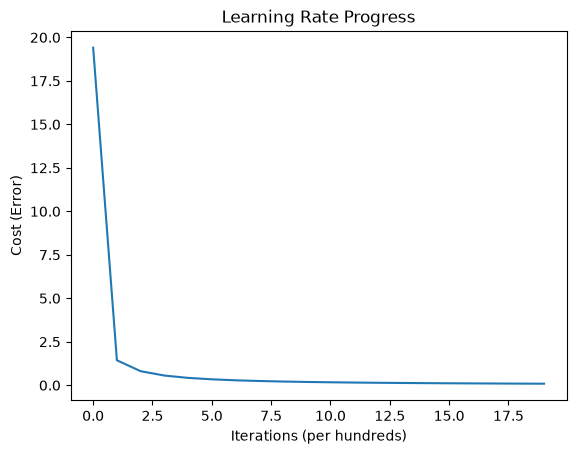

In [16]:
# Plotting the cost history
plt.plot(costs)
plt.ylabel('Cost (Error)')
plt.xlabel('Iterations (per hundreds)')
plt.title('Learning Rate Progress')
plt.show()